In [43]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import joblib
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder

In [44]:
df = pd.read_csv('../../../data/preprocessed/selected_features_dataset.csv')
X = df.drop(['price_per_m2'], axis=1)
y = df['price_per_m2']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
xgboost_model = joblib.load("../../../models/xgboost/xgboost_model_label_v3.joblib")
print("XGBoost model loaded successfully")

XGBoost model loaded successfully


In [46]:
label_classes = None
try:
    with open("../../../data/processed/label_encoders_selected.pkl", 'rb') as f:
        label_classes = pickle.load(f)
    print("Label classes loaded successfully")
    
    # Verify if we have proper classes
    if isinstance(label_classes, np.ndarray):
        print(f"Loaded {len(label_classes)} label classes")
except Exception as e:
    print(f"Error loading label encoder: {str(e)}")
    label_classes = None

Label classes loaded successfully
Loaded 96 label classes


In [47]:
def decode_labels(encoded_values, classes_array):
    if classes_array is None:
        return encoded_values
    
    try:
        # Create a temporary label encoder
        le = LabelEncoder()
        le.classes_ = classes_array
        
        # Handle both numeric and string encoded values
        if pd.api.types.is_numeric_dtype(encoded_values):
            return le.inverse_transform(encoded_values.astype(int))
        else:
            return encoded_values
    except Exception as e:
        print(f"Error decoding labels: {str(e)}")
        return encoded_values


In [48]:
y_pred_test = xgboost_model.predict(X_test)

In [49]:
analysis_dir = "../../../reports/address_analysis/"
os.makedirs(analysis_dir, exist_ok=True)

In [50]:
results_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred_test
})
if 'address_line_2' in X_test.columns:
    results_df['address_encoded'] = X_test['address_line_2'].values
    results_df['address'] = decode_labels(results_df['address_encoded'], label_classes)
    print(f"Decoded {len(results_df)} address labels")
else:
    results_df['address'] = 'Unknown'
    print("No address_line_2 column found")

Decoded 1855 address labels



Saved metrics for 91 addresses to ../../../reports/address_analysis/address_performance_metrics.csv

                        Top 10 Addresses by R²                        
                Address       R2        MAE  Sample_Size  Actual_Mean  Predicted_Mean
      Tuek L'ak Ti Muoy 0.959750  80.821839            7  4026.975714     3998.712158
              Tuek Thla 0.933237  84.938334           19  2879.700526     2849.895752
           Boeng Salang 0.931884  62.915583           12  3795.152500     3831.938232
                Dangkao 0.927593  50.108805           20  1450.408000     1439.734863
       Phnom Penh Thmei 0.914865  80.716569           52  2936.398654     2942.642090
    Phsar Depou Ti Muoy 0.911005  92.894912           10  3843.148000     3896.189941
       Stueng Mean Chey 0.884858 108.040820           36  3123.304722     3060.155273
Kilomaetr Lekh Prammuoy 0.881551  40.700744           19  1273.551053     1269.184570
            Tonle Basak 0.880609 123.805835          

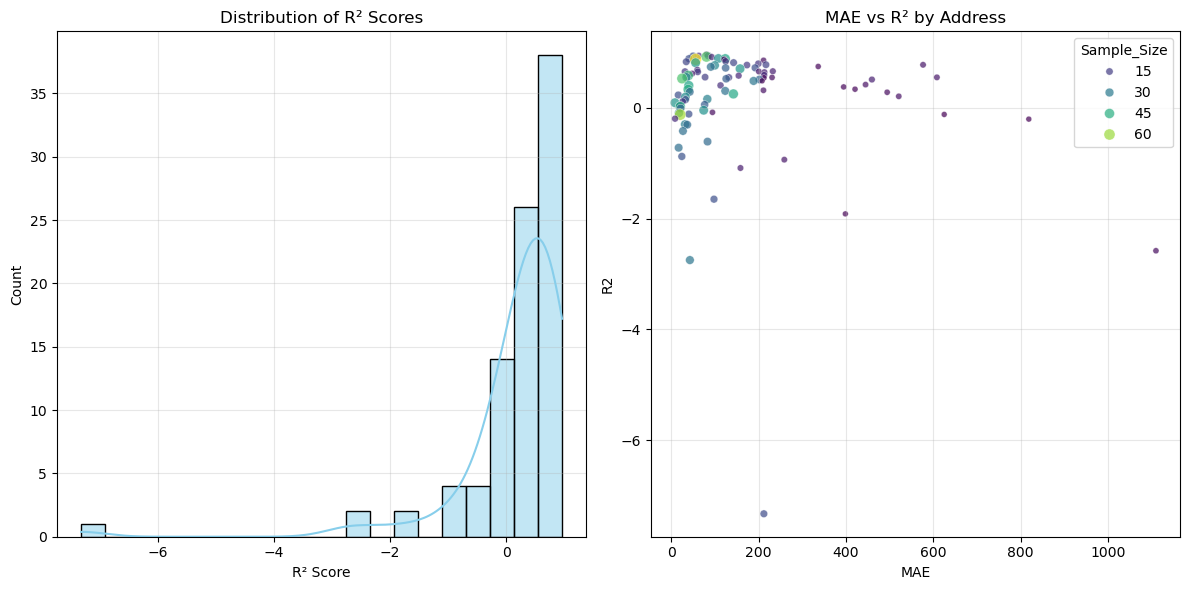


Creating detailed address plots...
Created 10 detailed address plots


In [53]:
# Calculate metrics for each address
if 'address' in results_df.columns and results_df['address'].nunique() > 1:
    address_metrics = []
    
    # Group by address and calculate metrics
    for address, group in results_df.groupby('address'):
        if len(group) >= 3:
            try:
                r2 = r2_score(group['actual'], group['predicted'])
                mae = mean_absolute_error(group['actual'], group['predicted'])
                address_metrics.append({
                    'Address': address,
                    'R2': r2,
                    'MAE': mae,
                    'Sample_Size': len(group),
                    'Actual_Mean': group['actual'].mean(),
                    'Predicted_Mean': group['predicted'].mean()
                })
            except:
                continue
    
    if address_metrics:
        # Create and sort metrics DataFrame
        metrics_df = pd.DataFrame(address_metrics).sort_values('R2', ascending=False)
        
        # Save metrics to CSV
        metrics_csv_path = os.path.join(analysis_dir, 'address_performance_metrics.csv')
        metrics_df.to_csv(metrics_csv_path, index=False)
        print(f"\nSaved metrics for {len(metrics_df)} addresses to {metrics_csv_path}")
        
        # Print performance summary
        print("\n" + "="*85)
        print(f"{'Top 10 Addresses by R²':^70}")
        print("="*85)
        print(metrics_df.head(10).to_string(index=False))
        
        print("\n" + "="*85)
        print(f"{'Bottom 10 Addresses by R²':^70}")
        print("="*85)
        print(metrics_df.tail(10).to_string(index=False))
        
        # Create visualizations
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        sns.histplot(metrics_df['R2'], bins=20, kde=True, color='skyblue')
        plt.title('Distribution of R² Scores')
        plt.xlabel('R² Score')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 2, 2)
        sns.scatterplot(data=metrics_df, x='MAE', y='R2', size='Sample_Size', 
                        hue='Sample_Size', palette='viridis', alpha=0.7)
        plt.title('MAE vs R² by Address')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(analysis_dir, 'address_performance_summary.png'))
        plt.show()
        
        # Create detailed address plots (top and bottom 5)
        print("\nCreating detailed address plots...")
        top_addresses = metrics_df.head(5)['Address'].tolist()
        bottom_addresses = metrics_df.tail(5)['Address'].tolist()
        selected_addresses = top_addresses + bottom_addresses
        
        for address in selected_addresses:
            addr_data = results_df[results_df['address'] == address]
            
            plt.figure(figsize=(10, 6))
            plt.scatter(addr_data['actual'], addr_data['predicted'], alpha=0.6, color='blue')
            plt.plot([addr_data['actual'].min(), addr_data['actual'].max()],
                     [addr_data['actual'].min(), addr_data['actual'].max()], 'r--')
            
            metrics = metrics_df[metrics_df['Address'] == address].iloc[0]
            plt.title(f"Address: {address}\n"
                     f"R²: {metrics['R2']:.3f} | MAE: {metrics['MAE']:.2f} | "
                     f"Samples: {metrics['Sample_Size']}")
            plt.xlabel('Actual Price per m²')
            plt.ylabel('Predicted Price per m²')
            plt.grid(True, alpha=0.3)
            
            # Save plot
            safe_name = "".join(c if c.isalnum() else "_" for c in str(address))
            plt.savefig(os.path.join(analysis_dir, f'address_{safe_name}.png'), bbox_inches='tight')
            plt.close()
        
        print(f"Created {len(selected_addresses)} detailed address plots")
    else:
        print("\nNo addresses with sufficient samples for metrics calculation")
else:
    print("\nNo valid address information available for analysis")


In [52]:
overall_r2 = r2_score(results_df['actual'], results_df['predicted'])
overall_mae = mean_absolute_error(results_df['actual'], results_df['predicted'])

print("\n" + "="*70)
print(f"{'Overall Model Performance':^70}")
print("="*70)
print(f"R²: {overall_r2:.4f}")
print(f"MAE: {overall_mae:.4f}")
print(f"Number of test samples: {len(results_df)}")
print(f"Number of addresses analyzed: {len(metrics_df) if 'metrics_df' in locals() else 0}")



                      Overall Model Performance                       
R²: 0.9920
MAE: 96.9227
Number of test samples: 1855
Number of addresses analyzed: 91
